# Latent Ewald Summation (LES), block by block: reproducing the original implementation with `xnns`

[LES (Cheng, *npj Comput Mater* **11**, 80, 2025)](https://doi.org/10.1038/s41524-025-01577-7)
adds **long-range interactions to any short-range MLIP**: a small MLP maps each
atom's invariant features to a hidden variable $q$ (eq 2; analogous to
environment-dependent partial charges, but unconstrained), and an Ewald
summation over the structure factor of $q$ supplies the long-range energy

$$E_{lr} = \frac{1}{V}\sum_{0<k<k_c} \frac{e^{-\sigma^2k^2/2}}{k^2}\,\lvert S(k)\rvert^2,
\qquad S(\mathbf k) = \sum_i q_i e^{i\mathbf k\cdot \mathbf r_i}. \tag{eqs 3–4}$$

In xnns this is `xnns.common.models.LatentEwald`, a **model-agnostic wrapper**
(like `ForceStressOutput`) that consumes the `"node_features"` every xnns model
now exposes, so *all* GNNs and short-range models (MACE, NequIP, Allegro, CACE,
SchNet, PhysNet, HDNNP, ANI) gain long-range physics the same way. This
notebook checks every block against the **original**
[`cace`](https://github.com/BingqingCheng/cace) `EwaldPotential` (the paper's
reference implementation) and ends with a whole-model CACE-LR weight-transplant
parity check, the same protocol as the other model series.

## 0. Setup: `float64` for exact comparison

In [1]:
# silence the expected warnings
import logging, warnings
logging.disable(logging.WARNING)
warnings.filterwarnings("ignore")

import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

import xnns, cace
from xnns.common.models import EwaldSummation, LatentEwald
print("xnns:", xnns.__version__, "| cace (original): 0.1.0")

xnns: 0.1.0 | cace (original): 0.1.0


## Block 1: The Ewald summation of a hidden variable  ·  eqs 3–5

`EwaldSummation` ports the original `cace.modules.EwaldPotential` math:
reciprocal-space sum on a k-grid limited by $|k| \le 2\pi/\mathrm{dl}$ with
hemisphere symmetry factors and triclinic support, tinfoil boundary conditions
(the $k=0$ term is omitted, so a net $q$ is fine), an optional Gaussian
self-interaction removal, the $1/r^6$ dispersion kernel (paper eq 5), and the
`erf`-converged real-space direct sum used for non-periodic structures.

We compare against upstream in float64 through its dtype-safe orthorhombic
reference loop (`compute_potential`); the production triclinic path is
float32-only upstream (its k-grid is hard-cast to float32), so it is compared
in float32 below.

In [2]:
from cace.modules.ewald import EwaldPotential

rng = np.random.default_rng(1)
pos = torch.tensor(rng.uniform(0, 6, (12, 3)))
q = torch.tensor(rng.normal(size=(12, 4)))          # 4-dimensional hidden variable
box = torch.tensor([6.0, 6.0, 6.0], dtype=torch.float64)

up = EwaldPotential(dl=1.9, sigma=1.0, remove_self_interaction=False)
mine = EwaldSummation(dl=1.9, sigma=1.0, remove_self_interaction=False)

pot_up, _ = up.compute_potential(pos, q, box)
print("electrostatic kernel (p=1):  |xnns - original| =",
      abs(float(mine.reciprocal(pos, q, torch.diag(box))) - float(pot_up.sum())))

pot6, _ = EwaldPotential(dl=1.9, exponent=6, remove_self_interaction=False).compute_potential(pos, q, box)
mine6 = EwaldSummation(dl=1.9, exponent=6, remove_self_interaction=False)
print("dispersion kernel   (p=6):  |xnns - original| =",
      abs(float(mine6.reciprocal(pos, q, torch.diag(box))) - float(pot6.sum())))

pot_rs, _ = up.compute_potential_realspace(pos, q)
print("molecular direct sum     :  |xnns - original| =",
      abs(float(mine.realspace(pos, q)) - float(pot_rs.sum())))

# float32: the upstream production (triclinic) forward path
torch.set_default_dtype(torch.float32)
cell32 = torch.tensor([[6.0, 0, 0], [1.2, 5.8, 0], [-0.7, 0.9, 6.3]], dtype=torch.float32)
data = {"positions": pos.float(), "cell": cell32.unsqueeze(0), "q": q.float(),
        "batch": torch.zeros(12, dtype=torch.long)}
e_up = float(EwaldPotential(dl=1.9, sigma=1.0, remove_self_interaction=False,
                            feature_key="q")(data)["ewald_potential"][0])
e_x = float(EwaldSummation(dl=1.9, sigma=1.0, remove_self_interaction=False)
            .reciprocal(pos.float(), q.float(), cell32))
print(f"triclinic forward (float32): rel diff = {abs(e_x - e_up)/abs(e_up):.2e}")
torch.set_default_dtype(torch.float64)

electrostatic kernel (p=1):  |xnns - original| = 1.1102230246251565e-16


dispersion kernel   (p=6):  |xnns - original| = 6.661338147750939e-16
molecular direct sum     :  |xnns - original| = 0.0
triclinic forward (float32): rel diff = 9.21e-08


### The reciprocal-space kernels

$e^{-\sigma^2 k^2/2}/k^2$ captures $1/r$ electrostatics; the $p=6$ kernel
(eq 5) captures London dispersion. The smearing $\sigma$ (default 1 Å) trades
real-space error against the required k-cutoff (paper fig 7).

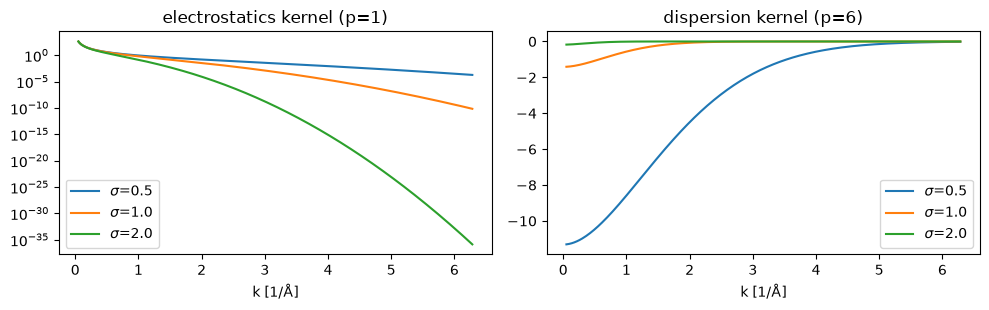

In [3]:
k = torch.linspace(0.05, 2 * np.pi, 300)
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
for sigma in (0.5, 1.0, 2.0):
    ew = EwaldSummation(sigma=sigma)
    ax[0].plot(k, ew._kfac(k ** 2), label=f"$\sigma$={sigma}")
    ew6 = EwaldSummation(sigma=sigma, exponent=6)
    ax[1].plot(k, ew6._kfac(k ** 2), label=f"$\sigma$={sigma}")
ax[0].set_title("electrostatics kernel (p=1)"); ax[0].set_yscale("log")
ax[1].set_title("dispersion kernel (p=6)")
for a in ax:
    a.set_xlabel("k [1/Å]"); a.legend()
plt.tight_layout(); plt.show()

## Block 2: Physics checks

* **Exact invariances**: rotation (including triclinic cells), translation,
  and shifts by full lattice vectors. One deliberate improvement over
  upstream: floating-point ties at the $|k| = k_c$ shell and in the grid size
  are resolved consistently, so rotating a cell can never drop a k shell
  (upstream truncates exactly and loses ~$10^{-4}$-level invariance for
  rotated cells).
* **Tinfoil boundary conditions**: for a *neutral* $q$, an isolated cluster in
  a large periodic box converges to the molecular direct sum; a net $q$ adds
  the constant background of the omitted $k=0$ term.

In [4]:
Q, _ = np.linalg.qr(np.random.default_rng(3).normal(size=(3, 3)))
if np.linalg.det(Q) < 0: Q[:, 0] *= -1
Qt = torch.tensor(Q)
cell_t = torch.tensor([[6.0, 0, 0], [1.2, 5.8, 0], [-0.7, 0.9, 6.3]])
ew = EwaldSummation()
e0 = ew.reciprocal(pos, q, cell_t)
print("rotation diff (triclinic):", abs(float(e0) - float(ew.reciprocal(pos @ Qt.T, q, cell_t @ Qt.T))))
print("lattice-shift diff       :", abs(float(e0) - float(ew.reciprocal(pos + cell_t[1], q, cell_t))))

qn = q - q.mean(dim=0, keepdim=True)      # neutral hidden variable
cluster = torch.tensor(np.random.default_rng(2).uniform(14, 16, (6, 3)))
qc = torch.tensor(np.random.default_rng(2).normal(size=(6, 1)));  qc -= qc.mean()
ew_fine = EwaldSummation(dl=1.0)
print("isolated cluster, 30 Å box vs direct sum (neutral q):",
      abs(float(ew_fine.realspace(cluster, qc))
          - float(ew_fine.reciprocal(cluster, qc, torch.eye(3, dtype=torch.float64) * 30))))

rotation diff (triclinic): 2.220446049250313e-16
lattice-shift diff       : 2.220446049250313e-16
isolated cluster, 30 Å box vs direct sum (neutral q): 7.723798462887232e-05


## Block 3: The latent charge head and the `node_features` contract  ·  eq 2

Every xnns model now returns its **invariant per-atom features** under the
``"node_features"`` output key (CACE: the concatenated symmetrized B features,
exactly what the paper uses; MACE/NequIP: the scalar channels; Allegro: the
environment-aggregated edge latents; SchNet/PhysNet: the feature vectors;
HDNNP/ANI: the descriptors) and advertises the width as ``node_feature_dim``.
`LatentEwald` puts the reference `cace-lr-fit` head on top: a bias-free
[24, 12] MLP plus a parallel bias-free linear layer, mapping features to the
``n_channels``-dimensional $q$.

In [5]:
from xnns.common.config import from_dict
from xnns.common.models import build_model, ForceStressOutput

cfg = from_dict({"model": {"name": "cace", "cutoff": 4.5, "n_interactions": 1, "n_rbf": 6,
    "extra": {"species": [1, 8], "n_atom_basis": 2, "n_radial_basis": 8,
              "max_l": 3, "max_nu": 3, "avg_num_neighbors": 9.0, "embed_receiver_nodes": True,
              "long_range": {"n_channels": 4, "dl": 1.9, "sigma": 1.0}}}})
model = build_model(cfg.model)          # the config hook wraps automatically
print(type(model).__name__, "around", type(model.model).__name__,
      "| node_feature_dim =", model.model.node_feature_dim)
print("q head:", model.q_net, "\n+ parallel", model.q_linear)

LatentEwald around CACE | node_feature_dim = 384
q head: Sequential(
  (0): Linear(in_features=384, out_features=24, bias=False)
  (1): SiLU()
  (2): Linear(in_features=24, out_features=12, bias=False)
  (3): SiLU()
  (4): Linear(in_features=12, out_features=4, bias=False)
) 
+ parallel Linear(in_features=384, out_features=4, bias=False)


## Capstone: whole-model CACE-LR transplant vs the original

The original composes `Cace` + `Atomwise` (SR energy) + `Atomwise` ($q$ head)
+ `EwaldPotential` + `FeatureAdd`; xnns composes `CACE` + `LatentEwald`. With
every weight copied across, the two are the same function (float32: the
upstream Ewald path is float32-only; each ingredient is verified at ~1e-16 in
float64 above and in `tests/test_cace.py`).

In [6]:
torch.set_default_dtype(torch.float32)
from cace.modules import BesselRBF as UpBessel, PolynomialCutoff as UpPoly, FeatureAdd
from cace.modules.atomwise import Atomwise
from cace.modules.forces import Forces
from cace.representations import Cace as UpCace
from cace.models.atomistic import NeuralNetworkPotential
from xnns.common.data import structure_to_graph

CUT, NRBF, NRB, NAB, LMAX, NU, T, NQ = 4.5, 6, 8, 2, 3, 3, 1, 4
torch.manual_seed(7)
rep = UpCace(zs=[1, 8], n_atom_basis=NAB, cutoff=CUT,
             radial_basis=UpBessel(cutoff=CUT, n_rbf=NRBF, trainable=True),
             cutoff_fn=UpPoly(cutoff=CUT, p=6), max_l=LMAX, max_nu=NU,
             num_message_passing=T, type_message_passing=["M", "Ar", "Bchi"],
             n_radial_basis=NRB, avg_num_neighbors=9.0, embed_receiver_nodes=True)
sr = Atomwise(n_layers=3, n_hidden=[32, 16], output_key="SR_energy", add_linear_nn=True)
qhead = Atomwise(n_layers=3, n_hidden=[24, 12], n_out=NQ, per_atom_output_key="q",
                 output_key="tot_q", residual=False, add_linear_nn=True, bias=False)
ep = cace.modules.EwaldPotential(dl=1.9, sigma=1.0, feature_key="q",
                                 output_key="ewald_potential",
                                 remove_self_interaction=False, aggregation_mode="sum")
eadd = FeatureAdd(feature_keys=["SR_energy", "ewald_potential"], output_key="CACE_energy")
nnp = NeuralNetworkPotential(representation=rep,
                             output_modules=[sr, qhead, ep, eadd,
                                             Forces(energy_key="CACE_energy",
                                                    forces_key="CACE_forces")])

cfg = from_dict({"model": {"name": "cace", "cutoff": CUT, "n_interactions": T, "n_rbf": NRBF,
    "extra": {"species": [1, 8], "n_atom_basis": NAB, "n_radial_basis": NRB,
              "max_l": LMAX, "max_nu": NU, "avg_num_neighbors": 9.0,
              "embed_receiver_nodes": True,
              "long_range": {"n_channels": NQ, "dl": 1.9, "sigma": 1.0}}}})
x = build_model(cfg.model)

rng = np.random.default_rng(11)
pos_np = rng.uniform(0, 6, (12, 3))
g = structure_to_graph({"pos": pos_np, "atomic_numbers": [1, 8] * 6,
                        "cell": np.eye(3) * 6.0, "pbc": [True] * 3}, CUT)
cell = g.cell[0]
data = {"positions": g.pos.clone().requires_grad_(True), "atomic_numbers": g.atomic_numbers,
        "edge_index": g.edge_index, "shifts": g.cell_shifts.to(cell.dtype) @ cell,
        "unit_shifts": g.cell_shifts.to(cell.dtype), "batch": g.batch,
        "cell": cell.unsqueeze(0)}
out_up = nnp(data, training=True)          # lazy-inits both Atomwise heads

with torch.no_grad():
    b = x.model
    b.embed_sender.copy_(rep.node_embedding_sender.embedding_weights)
    b.embed_receiver.copy_(rep.node_embedding_receiver.embedding_weights)
    b.rbf.freqs.copy_(rep.radial_basis.bessel_weights * CUT)
    b.radial_transform.weight.copy_(torch.stack(list(rep.radial_transform.weights)))
    for t, (memory, ar, bchi) in enumerate(rep.message_passing_list):
        xi = b.interactions[t]
        xi.memory.memory_coef.copy_(torch.stack(list(memory.memory_coef)))
        xi.message_ar.prefactor.copy_(torch.stack(list(ar.prefactor)))
        xi.message_ar.inv_r0.copy_(torch.stack(list(ar.invr0)))
        xi.message_bchi.h.weight.copy_(bchi.hnet[0].linear.weight)
        xi.message_bchi.h.bias.copy_(bchi.hnet[0].linear.bias)
    for j, dense in enumerate(sr.outnet):
        b.readout_mlp[2 * j].weight.copy_(dense.linear.weight)
        b.readout_mlp[2 * j].bias.copy_(dense.linear.bias)
    b.readout_linear.weight.copy_(sr.linear_nn.linear.weight)
    b.readout_linear.bias.copy_(sr.linear_nn.linear.bias)
    for j, dense in enumerate(qhead.outnet):
        x.q_net[2 * j].weight.copy_(dense.linear.weight)
    x.q_linear.weight.copy_(qhead.linear_nn.linear.weight)

E_up = out_up["CACE_energy"].sum()
F_up = -torch.autograd.grad(E_up, data["positions"])[0]
ox = ForceStressOutput(x)(g)
print(f"|dE|/|E|      = {abs(float(ox['energy']) - float(E_up))/abs(float(E_up)):.2e}")
print(f"max|dF|/max|F| = {((ox['forces'].detach() - F_up).abs().max()/F_up.abs().max()).item():.2e}")
print(f"max|dq|/max|q| = {((ox['latent_charges'].detach() - out_up['q']).abs().max()/out_up['q'].abs().max()).item():.2e}")
print(f"E_lr: xnns {float(ox['energy_lr']):.6g} | original {float(out_up['ewald_potential']):.6g}")

|dE|/|E|      = 4.77e-07
max|dF|/max|F| = 1.53e-06
max|dq|/max|q| = 2.09e-07
E_lr: xnns 4.02507e+08 | original 4.02507e+08


## Summary

| block | original `cace` | `xnns` | diff |
|---|---|---|---|
| latent charge head (eq 2) | `Atomwise` (bias-free MLP + linear) | `LatentEwald.q_net` + `q_linear` | 0 (same layers) |
| reciprocal Ewald, p=1 (eqs 3–4) | `EwaldPotential.compute_potential` | `EwaldSummation.reciprocal` | ~1e-16 (float64) |
| dispersion kernel, p=6 (eq 5) | same, `exponent=6` | same | ~1e-16 (float64) |
| molecular direct sum | `compute_potential_realspace` | `EwaldSummation.realspace` | ~1e-16 (float64) |
| production triclinic path | `compute_potential_triclinic` (float32-only) | same math, dtype-safe | ~1e-7 rel (float32) |
| **whole CACE-LR model** | rep + 2×Atomwise + Ewald + FeatureAdd | `LatentEwald(CACE)` | **float32 round-off** |

Documented deviations (both floating-point robustness fixes, not physics
changes): the k-grid follows the input dtype (upstream hard-casts to float32,
crashing float64), and exact ties at the $|k| = k_c$ shell resolve
consistently so the energy is exactly rotation-invariant. Also note upstream's
`remove_self_interaction=True` over-subtracts the self term for
multi-dimensional $q$ (once per channel); xnns subtracts it once (identical
for 1-D $q$ and for the default `remove_self_interaction=False`).

Because `LatentEwald` only needs the `"node_features"` contract, the same
wrapper (and the `model.extra["long_range"]` config hook) works for **every**
xnns model; see `tests/test_les.py::test_wraps_every_model`. Next:
`les_water_train_test.ipynb` reproduces the paper's bulk-water experiment.